In [13]:
import pandas as pd

df = pd.read_csv("loan_risk_prediction_dataset.csv")

In [14]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [15]:
df.shape

(5000, 10)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [17]:
df.isnull().sum()

,0
Age,0
Income,196
LoanAmount,0
CreditScore,194
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 Age
[56 69 46 32 60 25 38 36 40 28 41 53 57 20 39 19 61 47 55 50 29 42 66 44
 59 45 33 64 68 54 24 26 35 21 31 67 43 37 52 34 23 51 27 48 65 62 58 18
 22 30 49 63]

 Income
[48353. 57462. 44219. ... 58100. 58513. 58928.]

 LoanAmount
[31258. 23262. 26530. ... 18230. 12373. 23615.]

 CreditScore
[675. 586. 781. 549. 500. 835. 760. 599. 777. 382. 757. 597. 663.  nan
 639. 815. 407. 615. 413. 466. 560. 523. 561. 550. 825. 425. 505. 439.
 361. 582. 353. 645. 823. 435. 629. 443. 735. 581. 788. 700. 748. 569.
 316. 568. 518. 618. 537. 844. 584. 336. 402. 729. 538. 424. 487. 555.
 829. 691. 767. 552. 475. 765. 588. 349. 303. 799. 522. 834. 360. 655.
 323. 592. 328. 656. 664. 708. 565. 590. 452. 472. 311. 661. 776. 381.
 740. 525. 670. 327. 315. 576. 632. 782. 587. 337. 753. 465. 504. 544.
 695. 420. 558. 709. 609. 367. 519. 772. 685. 704. 791. 727. 514. 679.
 513. 397. 827. 848. 627. 464. 415. 449. 817. 331. 476. 715. 306. 384.
 697. 692. 346. 640. 725. 814. 428. 548. 430. 622. 842. 365. 40

In [20]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [22]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5000, 10)


In [23]:
df.isnull().sum()

,0
Age,0
Income,196
LoanAmount,0
CreditScore,194
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


In [24]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=np.number).columns

print("Categorical columns:")
print(list(categorical_cols))

print("\nNumerical columns:")
print(list(numerical_cols))

Categorical columns:
['Gender', 'Education', 'City', 'EmploymentType']

Numerical columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'LoanApproved']


In [25]:
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [26]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [27]:
df.isnull().sum()

,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
YearsExperience,0
Gender,0
Education,0
City,0
EmploymentType,0
LoanApproved,0


In [28]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,Bachelors,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           5000 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      5000 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        5000 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [30]:
df.to_csv("cleaned_loan_dataset.csv", index=False)

In [31]:
numerical_cols = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numerical_cols))

Numerical columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'LoanApproved']


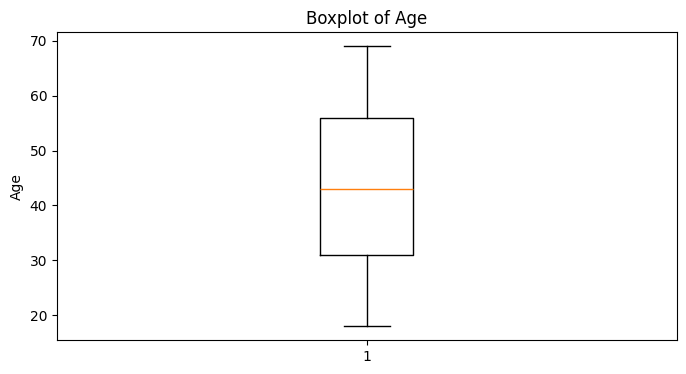

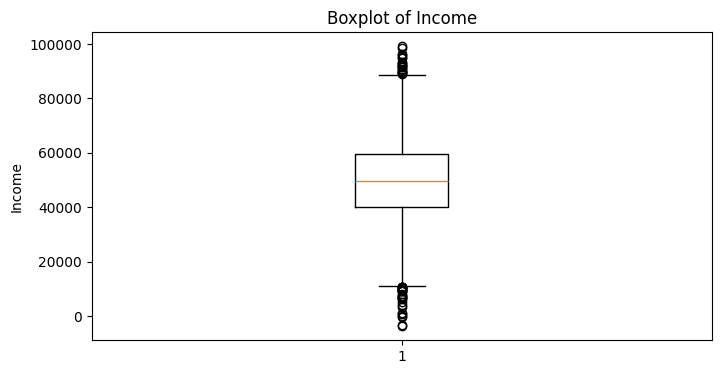

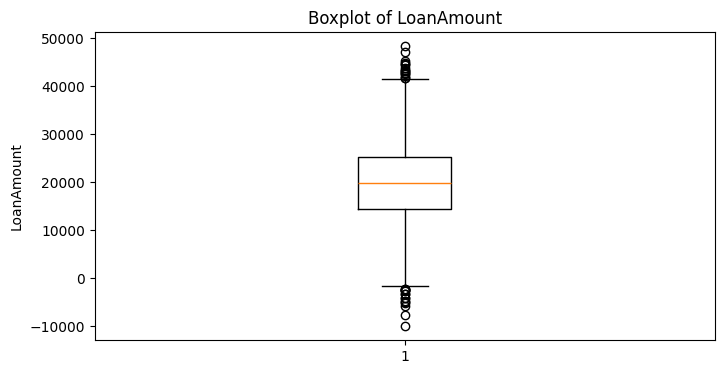

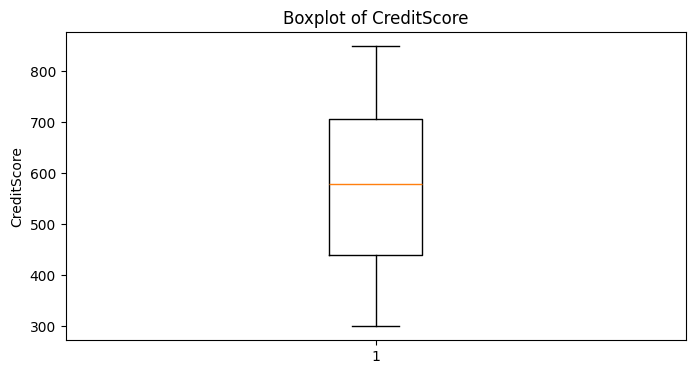

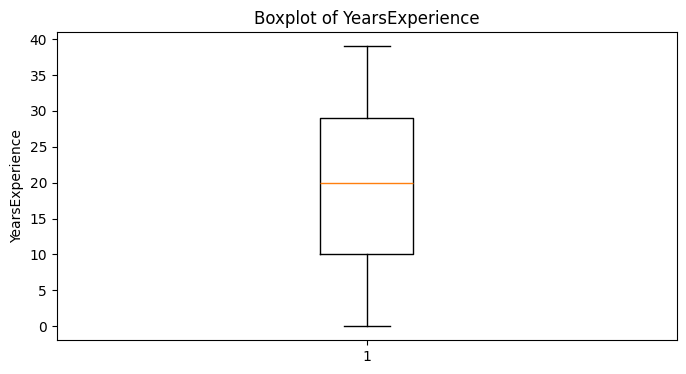

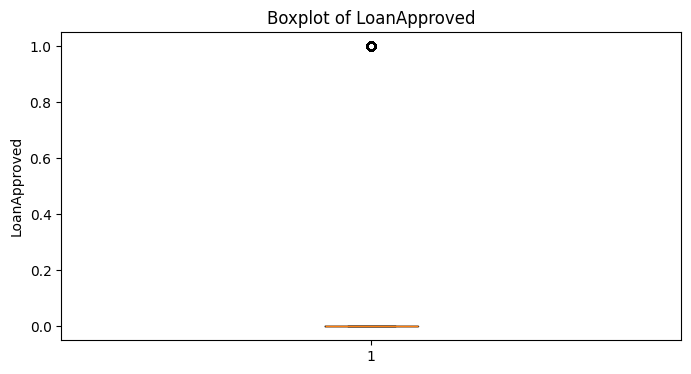

In [32]:
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

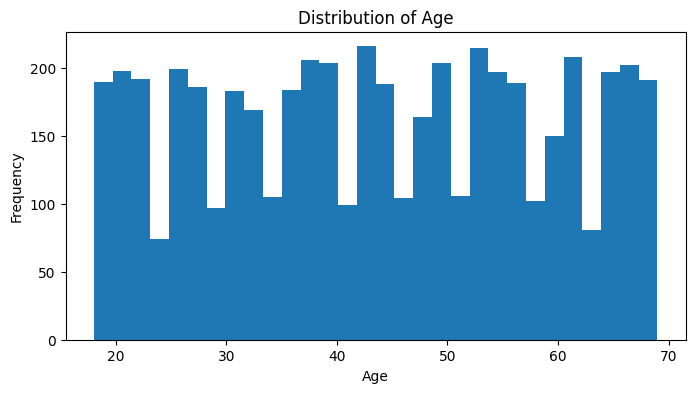

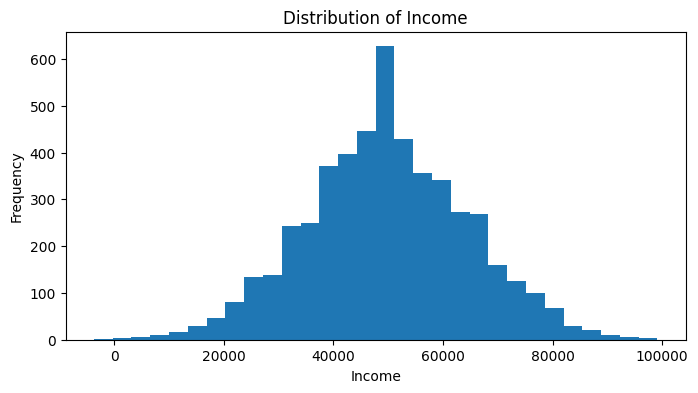

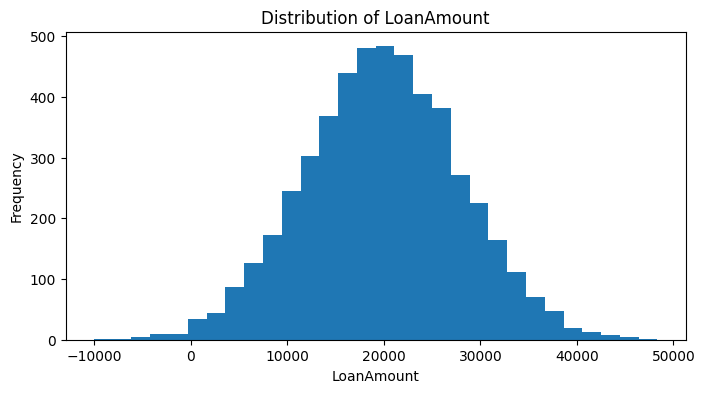

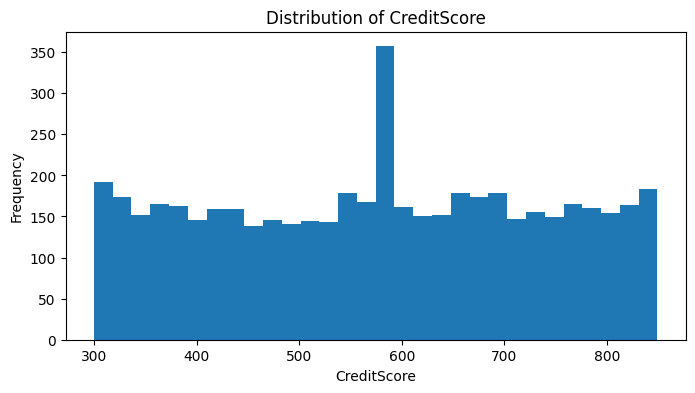

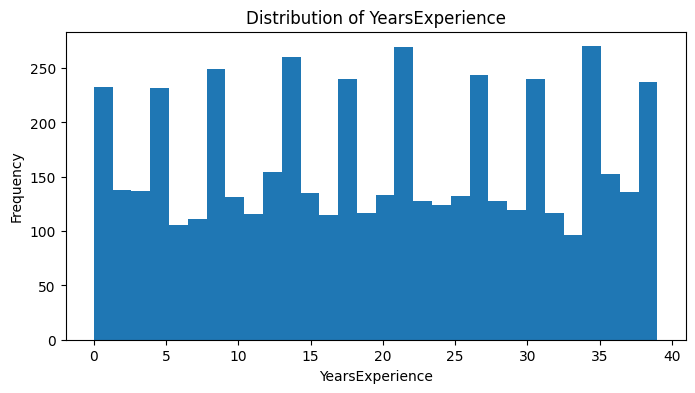

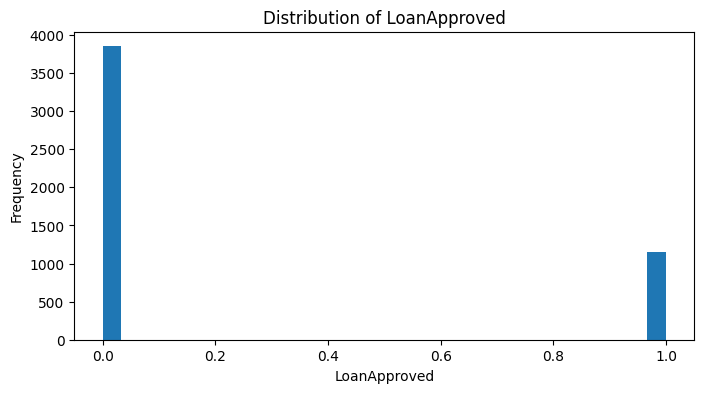

In [33]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

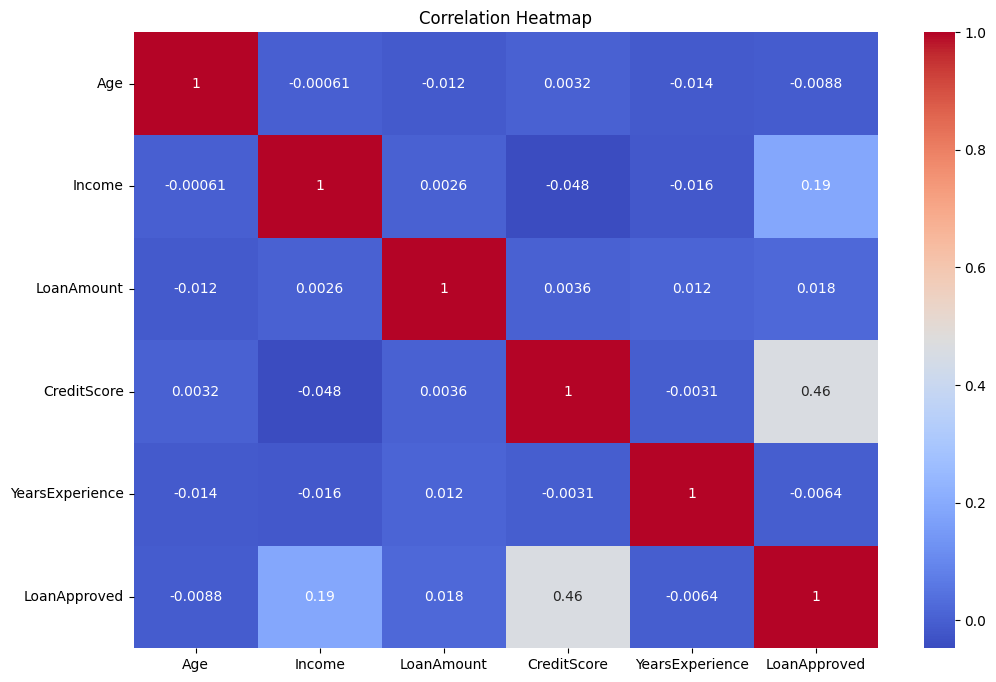

In [34]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [35]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Gender
Gender
Male      2541
Female    2459
Name: count, dtype: int64

Education
Education
Bachelors      1418
PhD            1199
Masters        1198
High School    1185
Name: count, dtype: int64

City
City
Chicago          1304
San Francisco    1257
Houston          1232
New York         1207
Name: count, dtype: int64

EmploymentType
EmploymentType
Self-Employed    1730
Unemployed       1660
Salaried         1610
Name: count, dtype: int64


In [36]:
print(df.columns.tolist())

['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved']


In [37]:
df["LoanApproved"].value_counts()

,count
LoanApproved,
0,3849
1,1151


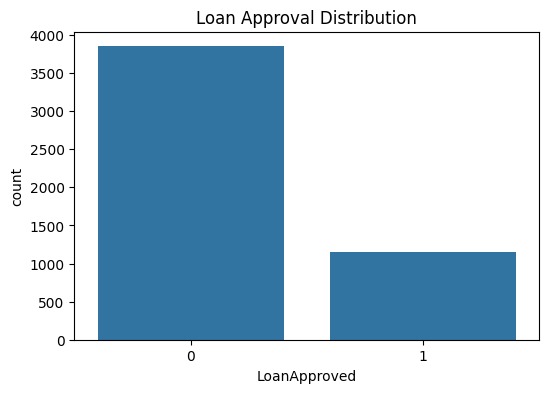

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="LoanApproved")
plt.title("Loan Approval Distribution")
plt.show()

In [39]:
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

In [40]:
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical features:")
print(list(categorical_features))

print("\nNumerical features:")
print(list(numerical_features))

Categorical features:
['Gender', 'Education', 'City', 'EmploymentType']

Numerical features:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']


In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 9)
Testing data: (1000, 9)


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'Education', 'City', 'EmploymentType'], dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [44]:
y_pred = logistic_model.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.885

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       770
           1       0.78      0.70      0.74       230

    accuracy                           0.89      1000
   macro avg       0.85      0.82      0.83      1000
weighted avg       0.88      0.89      0.88      1000



In [46]:
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

In [47]:
print(df.columns.tolist())

['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved']


In [48]:
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'Gender', 'Education', 'City', 'EmploymentType']
Target: LoanApproved


In [49]:
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical features:")
print(list(categorical_features))

print("\nNumerical features:")
print(list(numerical_features))

Categorical features:
['Gender', 'Education', 'City', 'EmploymentType']

Numerical features:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 9)
Testing data: (1000, 9)


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.885

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       770
           1       0.78      0.70      0.74       230

    accuracy                           0.89      1000
   macro avg       0.85      0.82      0.83      1000
weighted avg       0.88      0.89      0.88      1000



In [55]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 0.962


In [56]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.964


In [57]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.885
1,Decision Tree,0.962
2,Random Forest,0.964


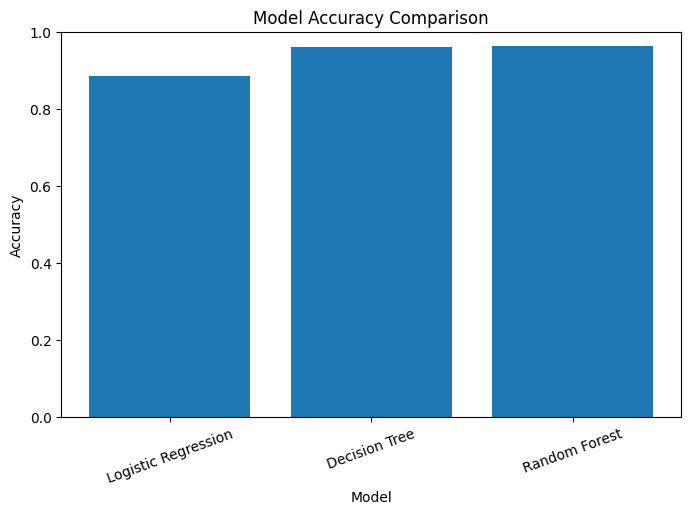

In [58]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

In [59]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       770
           1       0.95      0.89      0.92       230

    accuracy                           0.96      1000
   macro avg       0.96      0.94      0.95      1000
weighted avg       0.96      0.96      0.96      1000



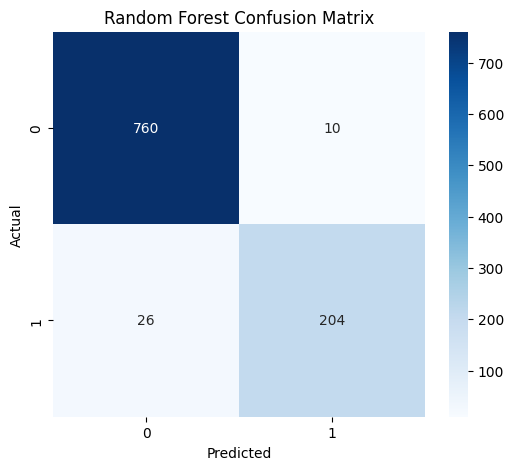

In [60]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [61]:
import joblib

joblib.dump(random_forest, "loan_approval_model.pkl")

['loan_approval_model.pkl']

In [62]:
from google.colab import files

files.download("loan_approval_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>